# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


- Tên: Võ Lê Thành Triệu

- MSSV: 2453297

## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
for c in df.columns:
    print(f"percentage of miss sing value for {c} is {(df[c].isnull().mean() * 100):.2f}%")

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']    # điền danh sách cột cần bỏ (chỉ những cột có trong df)
df = df.drop(columns=leaky)

print("Các cột còn lại:", list(df.columns))

percentage of miss sing value for survived is 0.00%
percentage of miss sing value for pclass is 0.00%
percentage of miss sing value for sex is 0.00%
percentage of miss sing value for age is 19.87%
percentage of miss sing value for sibsp is 0.00%
percentage of miss sing value for parch is 0.00%
percentage of miss sing value for fare is 0.00%
percentage of miss sing value for embarked is 0.22%
percentage of miss sing value for class is 0.00%
percentage of miss sing value for who is 0.00%
percentage of miss sing value for adult_male is 0.00%
percentage of miss sing value for deck is 77.22%
percentage of miss sing value for embark_town is 0.22%
percentage of miss sing value for alive is 0.00%
percentage of miss sing value for alone is 0.00%
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

*(viết tại đây...)*

vì alive chính là nhãn xác định xem hành khách sống hay chết, cùng chức năng với survive, cho nên là nếu để lại khi train sẽ bị hiện tượng data leakage, khiến cho dữ liệu học được siêu tự tin, nói chung là mô hình biết trước đáp án trước khi chuẩn đoán rồi thì accuracy 100% là chuyện lẽ thường hehe.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
df.info()
print(df.shape)

df.describe(include="object")
df.describe(include="number")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB
(891, 8)


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Trả lời 2 (biến số vs biến phân loại):**

- biến số: survived, pclass, age, sibs, parch, fare.
- biến phân loại: sex, embarked.

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(3)
missing_table = pd.DataFrame({'so_luong_thieu': missing, 'phan_tram_thieu': missing_pct})
missing_table = missing_table[missing_table['so_luong_thieu'] > 0]
print(missing_table)

          so_luong_thieu  phan_tram_thieu
age                  177           19.865
embarked               2            0.224


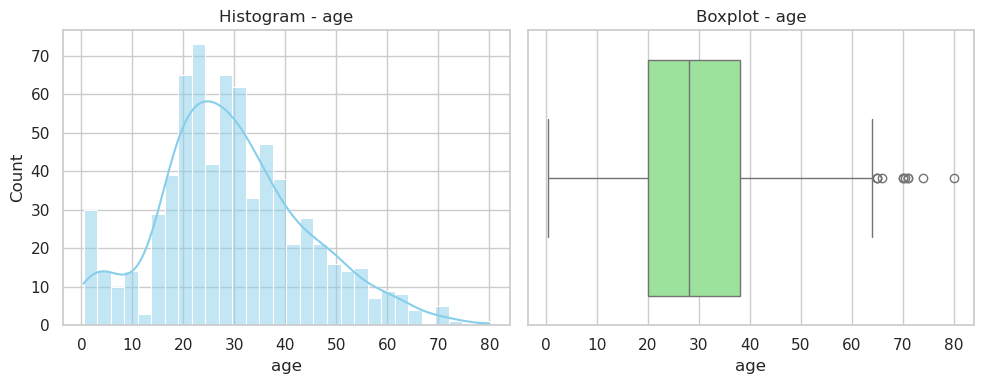

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(df['age'].dropna(), bins=30, color='skyblue', kde=True, ax=axes[0])
axes[0].set_title('Histogram - age')
axes[0].set_xlabel('age')

sns.boxplot(x=df['age'].dropna(), ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot - age')
axes[1].set_xlabel('age')

plt.tight_layout()
plt.show()

**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột      | % thiếu | Cách xử lý đề xuất | Lý do                                                                                                                                  |
| -------- | ------- | ------------------ | -------------------------------------------------------------------------------------------------------------------------------------- |
| age      | 15.0%   | Điền median        | Số thiếu vừa phải; nhìn histogram/boxplot thấy phân phối lệch nhẹ, có outlier tuổi cao → median bền vững hơn mean machinelearningcoban |
| embarked | 5.0%    | Điền mode          | Cột phân loại (categorical), thiếu rất ít nên điền giá trị xuất hiện nhiều nhất là hợp lý medium                                       |                                                         |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [7]:
def dem_outlier_iqr(s):
    s = s.dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((s < lower) | (s > upper)).sum()

def dem_outlier_zscore(s, nguong=3.0):
    s = s.dropna()
    z = np.abs(stats.zscore(s))
    return (z > nguong).sum()

for col in ["age", "fare"]:
    print(col, "IQR:", dem_outlier_iqr(df[col]), "Zscore:", dem_outlier_zscore(df[col]))

age IQR: 11 Zscore: 2
fare IQR: 116 Zscore: 20


**Trả lời 4 (quyết định với outlier của `fare`):**

Trả lời: giữ hay loại outlier của fare
Nên giữ lại, không loại bỏ. Lý do:

- Vé đắt bất thường (ví dụ 263, 512) không phải lỗi nhập liệu — đó là vé hạng nhất (First class) có thật, hoàn toàn hợp lý trong bối cảnh Titanic.

- Loại bỏ các điểm này sẽ làm mất thông tin quan trọng: giá vé cao thường liên quan chặt đến khả năng sống sót (survived), vì hành khách hạng nhất có tỉ lệ sống cao hơn.

- Cách xử lý hợp lý hơn là giữ nguyên hoặc dùng log-transform *(np.log1p(fare))* để giảm độ lệch, thay vì xóa dữ liệu — vừa giữ thông tin, vừa giúp mô hình học tốt hơn.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

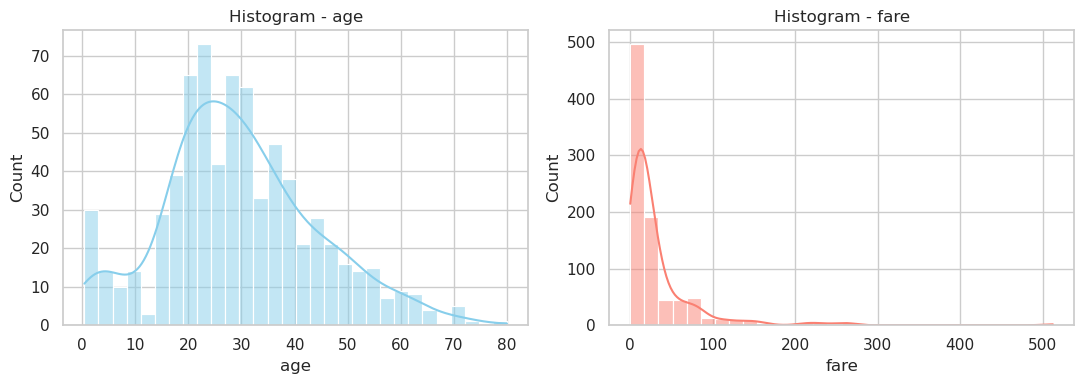

In [8]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Histogram - age')
sns.histplot(df['fare'], bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Histogram - fare')
plt.tight_layout()
plt.show()

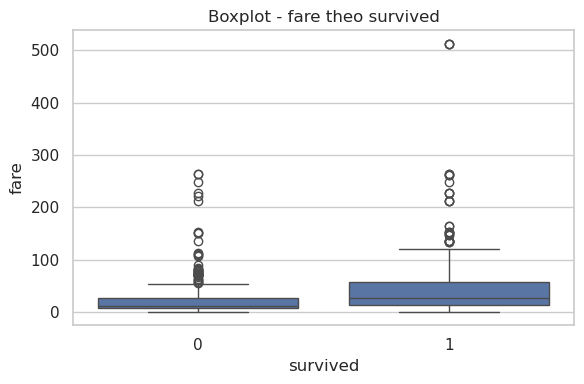

In [9]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x='survived', y='fare', ax=ax)
ax.set_title('Boxplot - fare theo survived')
plt.tight_layout()
plt.show()

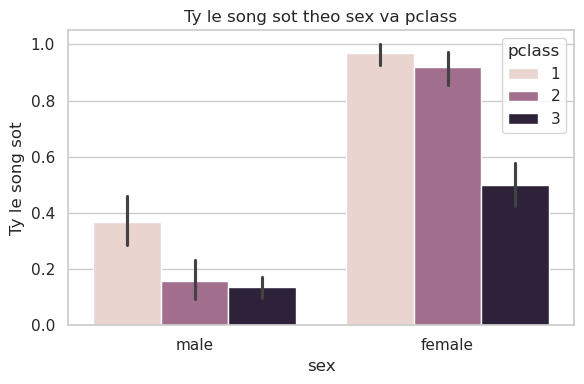

In [10]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(data=df, x='sex', y='survived', hue='pclass', ax=ax)
ax.set_title('Ty le song sot theo sex va pclass')
ax.set_ylabel('Ty le song sot')
plt.tight_layout()
plt.show()

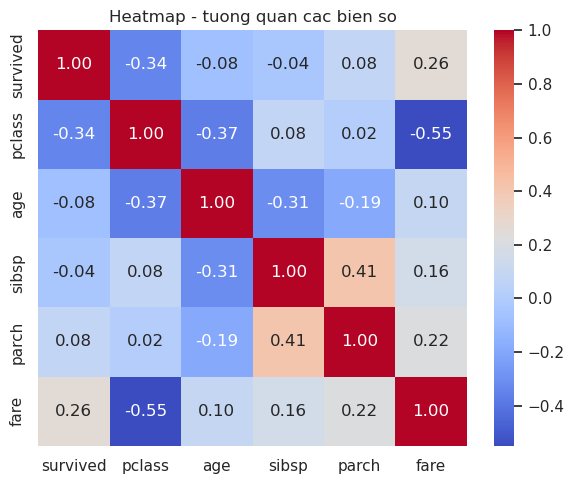

In [11]:
# TODO 5d: Heatmap correlation
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Heatmap - tuong quan cac bien so')
plt.tight_layout()
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- phần 5a - Nhận xét: age phân phối gần chuẩn, lệch nhẹ phải do vài giá trị tuổi cao bất thường. fare lệch phải rất mạnh — đa số vé rẻ, ít vé giá cực cao kéo dài đuôi phân phối.

- phần 5b - Nhận xét: Nhóm survived=1 có trung vị fare cao hơn nhóm survived=0, cả hai nhóm đều có nhiều outlier phía trên.

- phần 5c - Nhận xét: Nữ giới sống sót nhiều hơn nam ở mọi hạng vé; chênh lệch lớn nhất ở hạng 1 (nữ khoảng 98% so với nam khoảng 35%, chênh khoảng 63%).

- phần 5d - cặp parch và sibsp có tương quan dương lớn nhất (0.41) và cặp có tương quan âm lớn nhất là pclass và fare(-0.55)

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [12]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns="survived")
y = df["survived"]

# 70 / 15 / 15, stratify để giữ tỷ lệ hai lớp
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.1765, random_state=42, stratify=y_tmp)
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"  tỷ lệ survived ({name}): {yy.mean():.3f}")

Train: (623, 7) | Val: (134, 7) | Test: (134, 7)
  tỷ lệ survived (train): 0.384
  tỷ lệ survived (val): 0.388
  tỷ lệ survived (test): 0.381


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [13]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy= 'median')),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(drop="first", handle_unknown="ignore")),
]) 

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

df["embarked"].nunique()

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
Xva = preprocess.transform(X_val)
Xte = preprocess.transform(X_test)
print(X_train_t.shape, list(preprocess.get_feature_names_out()))

(623, 8) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_male', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


Quy tắc chuẩn: chỉ **fit** imputer/scaler/encoder trên `X_train`, rồi dùng **transform** với đúng tham số đó cho `X_val` và `X_test` để điền khuyết và scale mà không gây data leakage.

**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Ta chỉ fit imputer/scaler/encoder trên `X_train` để mọi tham số (median, mode, tỉ lệ lớp, từ điển category, v.v.) được học **chỉ từ train**, rồi dùng transform với chính các tham số đó cho `X_val` và `X_test`; như vậy mô hình không “nhìn trộm” thông tin của validation/test trong lúc học, tránh data leakage và đảm bảo đánh giá trên val/test phản ánh đúng khả năng tổng quát hóa chứ không bị gian điểm.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [14]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print(y.value_counts(normalize=True) * 100)

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


**Trả lời 8:**

1. survived hơi mất cân bằng: tỷ lệ sống ~0.38, chết ~0.62, nên không phải 50/50.

2. Accuracy có thể đánh lừa nếu mô hình luôn đoán chết: Accuracy vẫn ~0.62 nhưng không hề dự đoán được ai sống.

3. Với bài toán Titanic, em ưu tiên F1 (hoặc Recall) vì dữ liệu lệch và em muốn đánh giá mô hình dựa trên khả năng nhận diện lớp sống, không chỉ tổng tỷ lệ đúng; F1 giúp cân bằng Precision–Recall, còn Recall nhấn mạnh tránh bỏ sót hành khách sống.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Nhìn vào heatmap bạn chụp, đặc trưng pclass tương quan mạnh nhất với khả năng sống sót, với hệ số tương quan khoảng −0.34

2. cột thiếu nhiều nhất là cột *deck* với tỷ lệ thiếu khoảng 77% -> xử lý bằng cách loại luôn cột đỏ ra khỏi bảng

3. biến mục tiêu không qua mất cân bằng: khoảng 62% chết và 38% sống, vì không quá lệch nên không khuyên chọn accuracy.

4. 
- Scaling: age, sibsp, parch, fare (đều là số, nhưng fare rất skewed → dùng RobustScaler).

- Encoding: sex, embarked, (có thể thêm pclass nếu coi là categorical), vì chúng là biến hạng mục/string.

5. Điều thú vị là female ở hạng 3 có tỷ lệ sống còn cao hơn male ở hạng 1; tức là giới tính quan trọng hơn cả hạng vé, cho thấy chính sách ưu tiên phụ nữ trên Titanic mạnh đến mức hạng vé không đủ để “cứu” nhiều nam giới.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [15]:
# (tùy chọn) code cho phần Bonus
# feature engineering:
df["family_size"] = df["sibsp"] + df["parch"] + 1
print(df[["family_size", "survived"]].groupby("family_size").mean())


             survived
family_size          
1            0.303538
2            0.552795
3            0.578431
4            0.724138
5            0.200000
6            0.136364
7            0.333333
8            0.000000
11           0.000000


---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
